In [6]:
# import matplotlib.pyplot để trực quan háo đồ thị
import matplotlib.pyplot as plt

# import numpy để convert một list Xt và Yt thành ma trận cùng kich thước
import numpy as np

Bài tập 2: Lập trình

* Viết chương trình thực hiện GD cho f(x, y) = x^2 + 2y^2

* Khởi tạo (x0, y0) = (4, 2), η = 0.1, và lặp 100 lần hoặc cho đến khi 
∥∇f(xt, yt)∥ < 10^−6

* In ra (xt, yt) và f(xt, yt) sau mỗi 10 lần lặp.

* Vẽ quỹ đạo của (xt, yt) trên mặt phẳng 2D, cùng với đường đồng mức (contour plot)
của f(x, y) (Tương tự Day 19, phần này chúng ta có thể lấy trực tiếp code từ solution).

[4, 2] [3.2, 1.2] [2.56, 0.72] [2.048, 0.432] [1.6384, 0.2592] [1.31072, 0.15552] [1.0485760000000002, 0.09331199999999999] [0.8388608000000002, 0.055987199999999994] [0.6710886400000001, 0.033592319999999995] [0.5368709120000001, 0.020155391999999994] 
[0.4294967296000001, 0.012093235199999997] [0.3435973836800001, 0.007255941119999998] [0.27487790694400005, 0.004353564671999998] [0.21990232555520003, 0.0026121388031999987] [0.17592186044416003, 0.0015672832819199991] [0.140737488355328, 0.0009403699691519995] [0.11258999068426241, 0.0005642219814911997] [0.09007199254740993, 0.00033853318889471976] [0.07205759403792794, 0.00020311991333683184] [0.057646075230342354, 0.0001218719480020991] 
[0.04611686018427388, 7.312316880125945e-05] [0.03689348814741911, 4.387390128075567e-05] [0.029514790517935284, 2.63243407684534e-05] [0.02361183241434823, 1.579460446107204e-05] [0.018889465931478583, 9.476762676643223e-06] [0.015111572745182867, 5.686057605985934e-06] [0.012089258196146294, 3.41

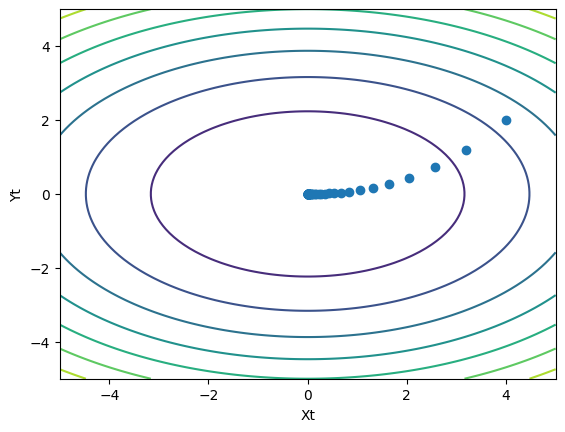

In [7]:
# tạo hàm tính gradient
def gradient(xt,yt):
    gradient_xt = 2*xt
    gradient_yt = 4*yt
    return gradient_xt,gradient_yt

# tạo hàm tính độ dài vector
def abs_f_xt(xt,yt):
    return (xt**2+yt**2)**0.5

# tạo hàm tính hàm mục tiêu
def gradient_descent(xt,yt,learning_rate):
    gradient_xt,gradient_yt =  gradient(xt,yt)
    next_xt = xt - learning_rate*gradient_xt
    next_yt = yt - learning_rate*gradient_yt
    return next_xt,next_yt

# tạo hàm để lưu các vector [xt, yt]
def loop(xt,yt,learning_rate,vector_xt,vector_yt):
    gradient_xt,gradient_yt = gradient(xt,yt)
    # tính đạo hàm theo x,y của f(x,y) tại Xt,Yt -> tính được Gradient
    vector_xt.append(xt)
    vector_yt.append(yt)
    # thêm vector [x0,y0] vào danh sách
    while abs_f_xt(gradient_xt,gradient_yt)>=10**-6:
        # tính cặp x,y tiếp theo
        next_xt,next_yt = gradient_descent(xt,yt,learning_rate)

        # cập nhật xt,yt để vòng lặp tiếp theo không quay về điểm xuất phát ban đầu
        xt = next_xt
        yt = next_yt
        
        # tính sẵn gradient để không bị về vòng lặp cũ
        gradient_xt,gradient_yt = gradient(next_xt,next_yt)
        
        # thêm x,y tiếp theo vào danh sách
        vector_xt.append(next_xt)
        vector_yt.append(next_yt)
        

# tạo hàm tính f(x,y)
def f(xt,yt):
    return xt**2 + 2*yt**2

# tạo hàm tính các phần tử trong list f(xt,yt)
def f_lst(vector_xt,vector_yt,f_xt):
    for i in range(len(vector_xt)):
        f_xt.append(f(vector_xt[i],vector_yt[i]))

# tạo hàm trực quan hóa vector [xt, yt]
def graph(vector_xt,vector_yt,f_xt):
    # vẽ hướng đi của vector[Xt, Yt]
    plt.scatter(vector_xt,vector_yt)
    plt.xlabel('Xt')
    plt.ylabel('Yt')

    # tạo đường đồng mức

    # tạo dải cách đều từ -5->5 với đủ 100 điểm trong khoảng đó
    x_grid = np.linspace(-5, 5, 100) 
    y_grid = np.linspace(-5, 5, 100) 

    # biến danh sách x_grid, y_grid thành ma trận 2D
    X,Y = np.meshgrid(x_grid,y_grid) 

    # tạo hàm f
    Z = X**2 + 2*Y**2
    plt.contour(X,Y,Z)
    plt.show()

# tạo hàm in ra các cặp vector [Xt, Yt] theo yêu cầu của đề bài
def answer(vector_xt,vector_yt):
    for i in range(0,len(vector_xt)):
        if i%10==0 and i!=0:
            print()
        print(f"[{vector_xt[i]}, {vector_yt[i]}]",end = ' ')

# làm theo yêu cầu của đề bài
vector_xt = []
vector_yt = []
f_xt = []
loop(4,2,0.1,vector_xt,vector_yt)
answer(vector_xt,vector_yt)
f_lst(vector_xt,vector_yt,f_xt)
graph(vector_xt,vector_yt,f_xt)


Bài tập 3: Thử nghiệm nâng cao (optional)

* Chạy lại chương trình với η = 0.01 và η = 0.4. So sánh tốc độ hội tụ (số lần lặp để abs([Xt,Yt])< 0.01).

* Thử với hàm mục tiêu khác: f(x, y) = x^2 + y^2. So sánh quỹ đạo GD với hàm ban đầu và rút ra nhận xét về tác động của hệ số 2y^2

[4, 2] [3.92, 1.92] [3.8416, 1.8432] [3.764768, 1.769472] [3.68947264, 1.69869312] [3.6156831872, 1.6307453952] [3.543369523456, 1.565515579392] [3.47250213298688, 1.5028949562163199] [3.4030520903271424, 1.442779157967667] [3.3349910485205996, 1.3850679916489603] 
[3.2682912275501876, 1.329665271983002] [3.202925402999184, 1.276478661103682] [3.1388668949392002, 1.2254195146595348] [3.076089557040416, 1.1764027340731533] [3.0145677658996077, 1.1293466247102273] [2.9542764105816155, 1.0841727597218183] [2.8951908823699832, 1.0408058493329455] [2.8372870647225836, 0.9991736153596277] [2.7805413234281318, 0.9592066707452426] [2.724930496959569, 0.9208384039154329] 
[2.670431887020378, 0.8840048677588156] [2.61702324927997, 0.8486446730484629] [2.5646827842943707, 0.8146988861265244] [2.513389128608483, 0.7821109306814634] [2.4631213460363135, 0.7508264934542049] [2.413858919115587, 0.7207934337160368] [2.3655817407332753, 0.6919616963673954] [2.31827010591861, 0.6642832285126995] [2.2719

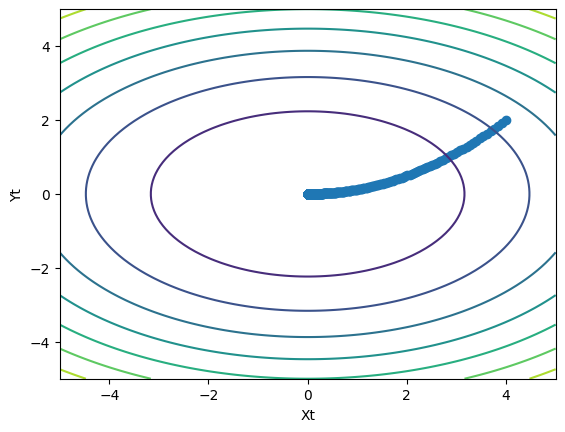

In [8]:
# trường hợp learning rate = 0,01
vector_xt_1 = []
vector_yt_1 = []
f_xt_1 = []
loop(4,2,0.01,vector_xt_1,vector_yt_1)
answer(vector_xt_1,vector_yt_1)
f_lst(vector_xt_1,vector_yt_1,f_xt_1)
graph(vector_xt_1,vector_yt_1,f_xt_1)

[4, 2] [0.7999999999999998, -1.2000000000000002] [0.15999999999999992, 0.7200000000000002] [0.03199999999999997, -0.43200000000000016] [0.0063999999999999925, 0.2592000000000001] [0.0012799999999999982, -0.1555200000000001] [0.0002559999999999995, 0.09331200000000006] [5.119999999999989e-05, -0.05598720000000004] [1.0239999999999976e-05, 0.03359232000000004] [2.0479999999999946e-06, -0.020155392000000022] 
[4.095999999999988e-07, 0.012093235200000017] [8.191999999999972e-08, -0.007255941120000012] [1.6383999999999943e-08, 0.0043535646720000085] [3.2767999999999877e-09, -0.0026121388032000056] [6.553599999999972e-10, 0.0015672832819200039] [1.3107199999999944e-10, -0.0009403699691520025] [2.6214399999999883e-11, 0.0005642219814912016] [5.242879999999975e-12, -0.00033853318889472107] [1.0485759999999952e-12, 0.00020311991333683268] [2.0971519999999899e-13, -0.00012187194800209963] 
[4.1943039999999777e-14, 7.312316880125978e-05] [8.388607999999957e-15, -4.387390128075587e-05] [1.67772159

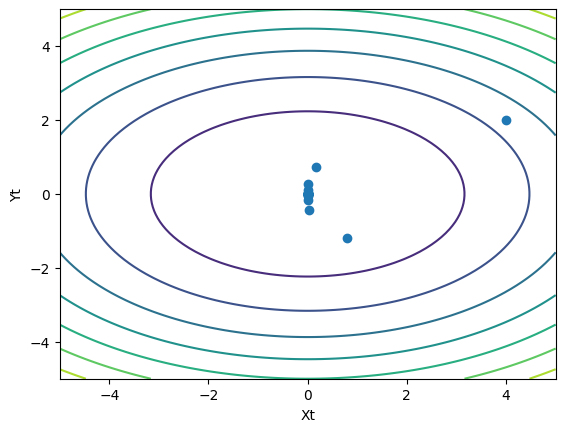

In [9]:
# trường hợp learning rate = 0,4
vector_xt_2 = []
vector_yt_2 = []
f_xt_2 = []
loop(4,2,0.4,vector_xt_2,vector_yt_2)
answer(vector_xt_2,vector_yt_2)
f_lst(vector_xt_2,vector_yt_2,f_xt_2)
graph(vector_xt_2,vector_yt_2,f_xt_2)

[4, 2] [3.2, 1.6] [2.56, 1.28] [2.048, 1.024] [1.6384, 0.8192] [1.31072, 0.65536] [1.0485760000000002, 0.5242880000000001] [0.8388608000000002, 0.4194304000000001] [0.6710886400000001, 0.33554432000000006] [0.5368709120000001, 0.26843545600000007] 
[0.4294967296000001, 0.21474836480000006] [0.3435973836800001, 0.17179869184000005] [0.27487790694400005, 0.13743895347200002] [0.21990232555520003, 0.10995116277760002] [0.17592186044416003, 0.08796093022208001] [0.140737488355328, 0.070368744177664] [0.11258999068426241, 0.056294995342131206] [0.09007199254740993, 0.04503599627370496] [0.07205759403792794, 0.03602879701896397] [0.057646075230342354, 0.028823037615171177] 
[0.04611686018427388, 0.02305843009213694] [0.03689348814741911, 0.018446744073709553] [0.029514790517935284, 0.014757395258967642] [0.02361183241434823, 0.011805916207174114] [0.018889465931478583, 0.009444732965739291] [0.015111572745182867, 0.0075557863725914335] [0.012089258196146294, 0.006044629098073147] [0.00967140

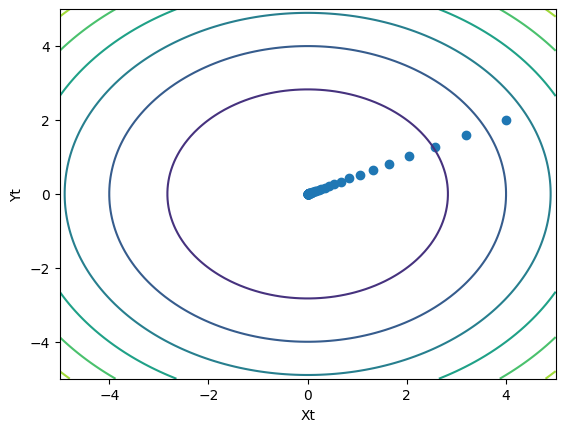

In [ ]:
# hàm mục tiêu mới là x^2+y^2
# tạo hàm tính gradient
def new_gradient(xt,yt):
    gradient_xt = 2*xt
    gradient_yt = 2*yt
    return gradient_xt,gradient_yt

# tạo hàm tính hàm mục tiêu
def new_gradient_descent(xt,yt,learning_rate):
    gradient_xt,gradient_yt =  new_gradient(xt,yt)
    next_xt = xt - learning_rate*gradient_xt
    next_yt = yt - learning_rate*gradient_yt
    return next_xt,next_yt

# tạo hàm để lưu các vector [xt, yt]
def new_loop(xt,yt,learning_rate,vector_xt,vector_yt):
    gradient_xt,gradient_yt = new_gradient(xt,yt)
    # tính đạo hàm theo x,y của f(x,y) tại Xt,Yt -> tính được Gradient
    vector_xt.append(xt)
    vector_yt.append(yt)
    # thêm vector [x0,y0] vào danh sách
    while abs_f_xt(gradient_xt,gradient_yt)>=10**-6:
        # tính cặp x,y tiếp theo
        next_xt,next_yt = new_gradient_descent(xt,yt,learning_rate)

        # cập nhật xt,yt để vòng lặp tiếp theo không quay về điểm xuất phát ban đầu
        xt = next_xt
        yt = next_yt
        
        # tính sẵn gradient để không bị về vòng lặp cũ
        gradient_xt,gradient_yt = new_gradient(next_xt,next_yt)
        
        # thêm x,y tiếp theo vào danh sách
        vector_xt.append(next_xt)
        vector_yt.append(next_yt)

# tạo hàm trực quan hóa vector [xt, yt]
def new_graph(vector_xt,vector_yt,f_xt):
    # vẽ hướng đi của vector[Xt, Yt]
    plt.scatter(vector_xt,vector_yt)
    plt.xlabel('Xt')
    plt.ylabel('Yt')

    # tạo đường đồng mức

    # tạo dải cách đều từ -5->5 với đủ 100 điểm trong khoảng đó
    x_grid = np.linspace(-5, 5, 100) 
    y_grid = np.linspace(-5, 5, 100) 

    # biến danh sách x_grid, y_grid thành ma trận 2D
    X,Y = np.meshgrid(x_grid,y_grid) 

    # tạo hàm f
    Z = X**2 + Y**2
    plt.contour(X,Y,Z)
    plt.show()

# làm theo yêu cầu của đề bài
new_vector_xt = []
new_vector_yt = []
new_f_xt = []
new_loop(4,2,0.1,new_vector_xt,new_vector_yt)
answer(new_vector_xt,new_vector_yt)
f_lst(new_vector_xt,new_vector_yt,new_f_xt)
new_graph(new_vector_xt,new_vector_yt,new_f_xt)


Kết luận của tôi sau khi so sánh quỹ đạo của 2 hàm:
* Hệ số của y^2 sẽ quyết định độ cong của con đường của vector [Xt, Yt]